# 01 - Data Understanding, Cleaning, Missing Values, Preprocessing, ICD-9 Grouping, EDA

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import (
    load_raw_data, basic_clean, create_target, add_diag_groups,
    split_train_test, fit_near_constant_cols, drop_cols,
    handle_missing_values, fit_categories, apply_categories,
)

OUTPUT_FIG_DIR = "../outputs/figures"

## 1. Data understanding

In [2]:
df_raw, ids_mapping = load_raw_data("../input")
print(df_raw.shape)
df_raw.info()

(101766, 50)
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications   

In [3]:
#kiem tra ty le '?' o tung cot (truoc khi thay bang NaN)
missing_mark_pct = (df_raw == '?').mean().sort_values(ascending=False)
missing_mark_pct[missing_mark_pct > 0]

weight               0.968585
medical_specialty    0.490822
payer_code           0.395574
race                 0.022336
diag_3               0.013983
diag_2               0.003518
diag_1               0.000206
dtype: float64

In [4]:
df_raw['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

## 2. Cleaning (rule-based) + tao target + gom nhom ICD-9

In [5]:
df_step1 = basic_clean(df_raw)
df_step1 = create_target(df_step1)
df_step1 = add_diag_groups(df_step1)
df_step1.shape

[basic_clean] Da loai 2423 dong (expired/hospice). Con lai 99343 dong.


(99343, 53)

## 3. Chia train/test theo patient_nbr

In [6]:
train_df, test_df = split_train_test(df_step1)

[split_train_test] Train: 79541 dong / Test: 19802 dong
[split_train_test] Ty le target - train: 0.1144, test: 0.1119  (GroupShuffleSplit khong ho tro stratify that su khi group theo patient_nbr, nen chi kiem tra lai ty le sau khi chia; neu lech nhieu, can can nhac StratifiedGroupKFold cua sklearn >=1.0)


In [7]:
from scipy.stats import chi2_contingency

# Kiem tra xem viec THIEU du lieu o cac cot missing-nhieu co lien quan
# den target khong (thay vi chi dien "Unknown" roi bo qua)
for col in ["medical_specialty", "payer_code", "race"]:
    ct = pd.crosstab(train_df[col].isna(), train_df["target"])
    chi2, p, dof, exp = chi2_contingency(ct)
    ket_luan = "co lien quan den target" if p < 0.05 else "chua thay lien quan ro"
    print(f"{col}: ty le thieu = {train_df[col].isna().mean():.2%}, "
          f"chi-square p-value = {p:.4g} ({ket_luan})")

medical_specialty: ty le thieu = 48.92%, chi-square p-value = 1.981e-05 (co lien quan den target)
payer_code: ty le thieu = 39.68%, chi-square p-value = 0.0738 (chua thay lien quan ro)
race: ty le thieu = 2.28%, chi-square p-value = 1.976e-05 (co lien quan den target)


## 4. Cac buoc fit tren train, ap dung lai cho test

### 4.1 Drop cot gan hang so (fit tren train)

In [8]:
dropped_cols = fit_near_constant_cols(train_df)
train_df = drop_cols(train_df, dropped_cols)
test_df = drop_cols(test_df, dropped_cols)
train_df.shape, test_df.shape

[fit_near_constant_cols] Cot se drop (fit tren train): ['examide', 'citoglipton', 'acetohexamide', 'troglitazone', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


((79541, 46), (19802, 46))

### 4.2 Missing values

In [9]:
train_df = handle_missing_values(train_df)
test_df = handle_missing_values(test_df)

[handle_missing_values] Cac cot con NaN sau xu ly:
diag_1      15
diag_2     296
diag_3    1169
dtype: int64
[handle_missing_values] Cac cot con NaN sau xu ly:
diag_1      5
diag_2     60
diag_3    250
dtype: int64


### 4.3 Kieu du lieu categorical (fit category tren train)

In [10]:
categories = fit_categories(train_df)
train_df = apply_categories(train_df, categories)
test_df = apply_categories(test_df, categories)
train_df.dtypes

encounter_id                   int64
patient_nbr                    int64
race                        category
gender                      category
age                         category
admission_type_id           category
discharge_disposition_id    category
admission_source_id         category
time_in_hospital               int64
payer_code                  category
medical_specialty           category
num_lab_procedures             int64
num_procedures                 int64
num_medications                int64
number_outpatient              int64
number_emergency               int64
number_inpatient               int64
diag_1                           str
diag_2                           str
diag_3                           str
number_diagnoses               int64
max_glu_serum               category
A1Cresult                   category
metformin                        str
repaglinide                      str
nateglinide                      str
chlorpropamide                   str
g

## 5. Kiem tra sau khi chia (can bang target, khong trung benh nhan)

In [11]:
print('Ty le target - train:', train_df['target'].mean())
print('Ty le target - test :', test_df['target'].mean())
trung_benh_nhan = set(train_df['patient_nbr']) & set(test_df['patient_nbr'])
print('So benh nhan trung train/test (phai = 0):', len(trung_benh_nhan))

Ty le target - train: 0.11438126249355678
Ty le target - test : 0.11190788809211191
So benh nhan trung train/test (phai = 0): 0


In [12]:
train_df = train_df.drop(columns=["patient_nbr", "encounter_id"])
test_df = test_df.drop(columns=["patient_nbr", "encounter_id"])

## 6. EDA

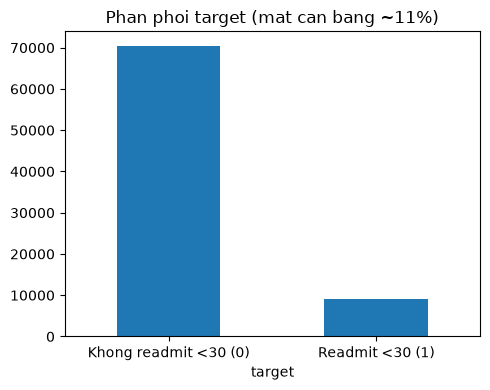

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
train_df['target'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xticklabels(['Khong readmit <30 (0)', 'Readmit <30 (1)'], rotation=0)
ax.set_title('Phan phoi target (mat can bang ~11%)')
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/target_distribution.png", dpi=150)
plt.show()

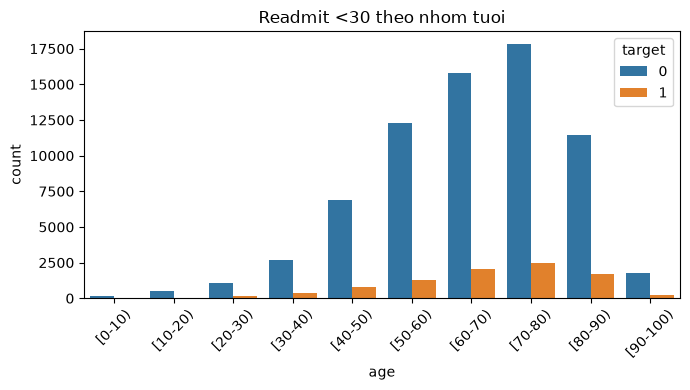

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=train_df, x='age', hue='target', ax=ax,
              order=sorted(train_df['age'].unique()))
ax.set_title('Readmit <30 theo nhom tuoi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/age_vs_target.png", dpi=150)
plt.show()

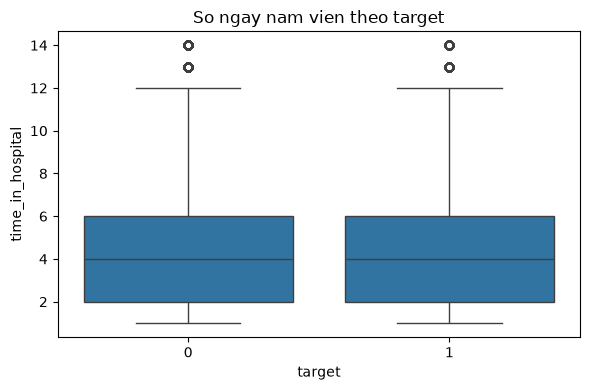

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=train_df, x='target', y='time_in_hospital', ax=ax)
ax.set_title('So ngay nam vien theo target')
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/time_in_hospital_vs_target.png", dpi=150)
plt.show()

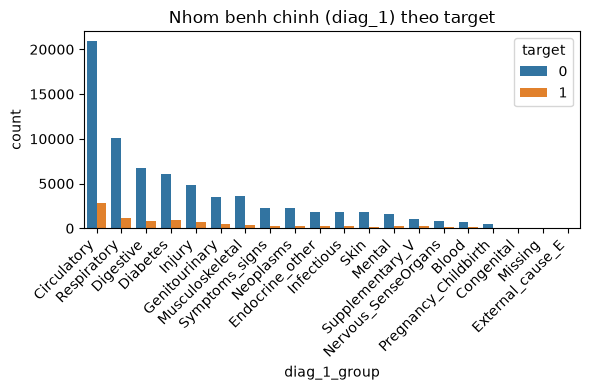

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=train_df, x='diag_1_group', hue='target', ax=ax,
              order=train_df['diag_1_group'].value_counts().index)
ax.set_title('Nhom benh chinh (diag_1) theo target')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/diag1_group_vs_target.png", dpi=150)
plt.show()

number_inpatient      0.168906
number_emergency      0.059015
number_diagnoses      0.053762
time_in_hospital      0.046483
num_medications       0.039945
num_lab_procedures    0.025028
number_outpatient     0.020348
num_procedures       -0.014765
Name: target, dtype: float64


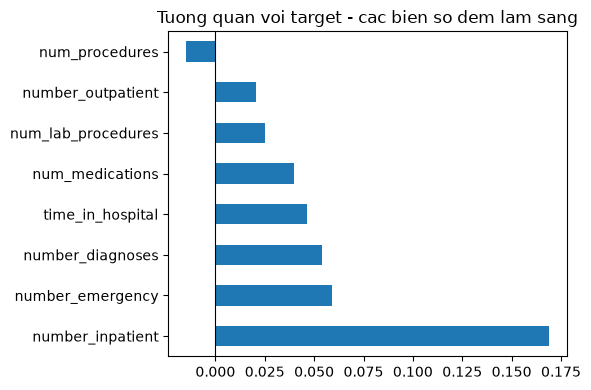

In [17]:
# --- 6.1 Cac bien so dem lam sang vs target ---
num_cols = [
    "number_inpatient", "number_emergency", "number_outpatient",
    "num_medications", "num_lab_procedures", "num_procedures",
    "time_in_hospital", "number_diagnoses",
]
corr_target = (
    train_df[num_cols + ["target"]].corr()["target"].drop("target")
    .sort_values(key=abs, ascending=False)
)
print(corr_target)

fig, ax = plt.subplots(figsize=(6, 4))
corr_target.plot(kind="barh", ax=ax)
ax.set_title("Tuong quan voi target - cac bien so dem lam sang")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/numeric_corr_with_target.png", dpi=150)
plt.show()

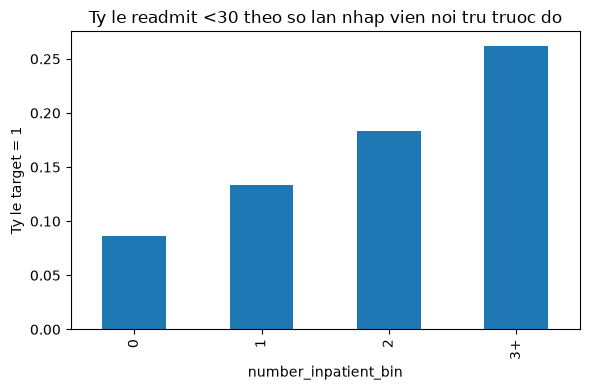

In [18]:
# --- 6.2 number_inpatient theo bin (feature manh nhat) ---
fig, ax = plt.subplots(figsize=(6, 4))
bins = [0, 1, 2, 3, train_df["number_inpatient"].max() + 1]
labels = ["0", "1", "2", "3+"]
train_df["number_inpatient_bin"] = pd.cut(
    train_df["number_inpatient"], bins=bins, labels=labels,
    right=False, include_lowest=True
)
rate_by_bin = train_df.groupby("number_inpatient_bin", observed=True)["target"].mean()
rate_by_bin.plot(kind="bar", ax=ax)
ax.set_title("Ty le readmit <30 theo so lan nhap vien noi tru truoc do")
ax.set_ylabel("Ty le target = 1")
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/number_inpatient_vs_target.png", dpi=150)
plt.show()
# xoa cot tam sau khi ve xong, khong luu vao file
train_df = train_df.drop(columns=["number_inpatient_bin"])

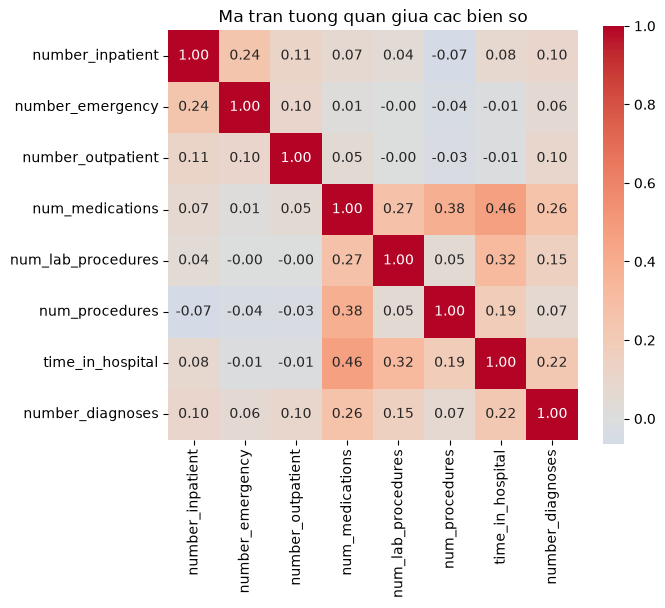

In [19]:
# --- 6.3 Ma tran tuong quan giua cac bien so ---
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(train_df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True)
ax.set_title("Ma tran tuong quan giua cac bien so")
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/numeric_corr_heatmap.png", dpi=150)
plt.show()

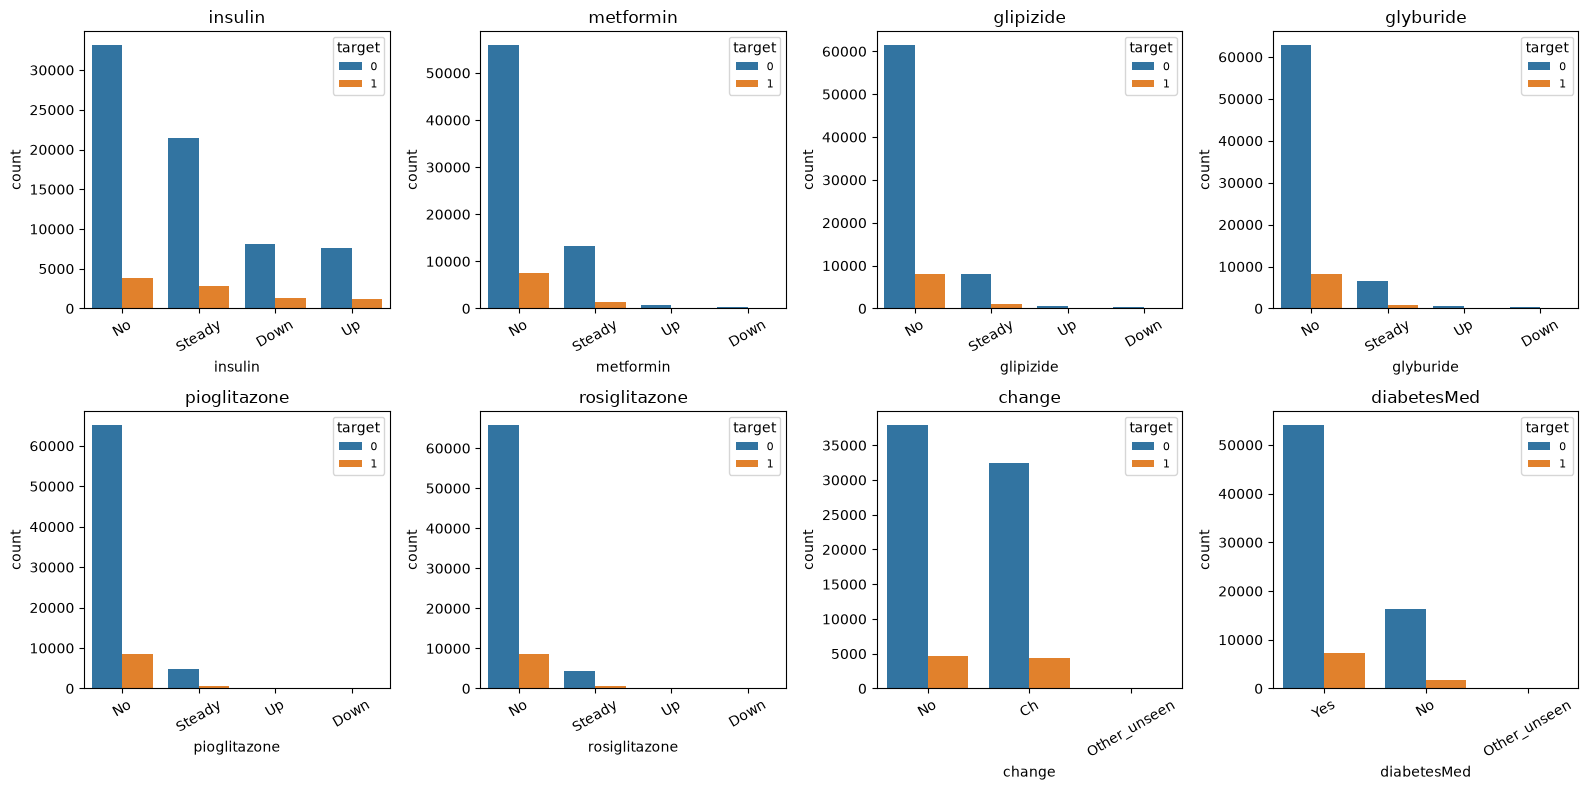

In [20]:
# --- 6.4 Nhom thuoc dieu tri tieu duong vs target ---
med_cols = ["insulin", "metformin", "glipizide", "glyburide",
            "pioglitazone", "rosiglitazone", "change", "diabetesMed"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), med_cols):
    order = train_df[col].value_counts().index
    sns.countplot(data=train_df, x=col, hue="target", ax=ax, order=order)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="target", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/medication_cols_vs_target.png", dpi=150)
plt.show()

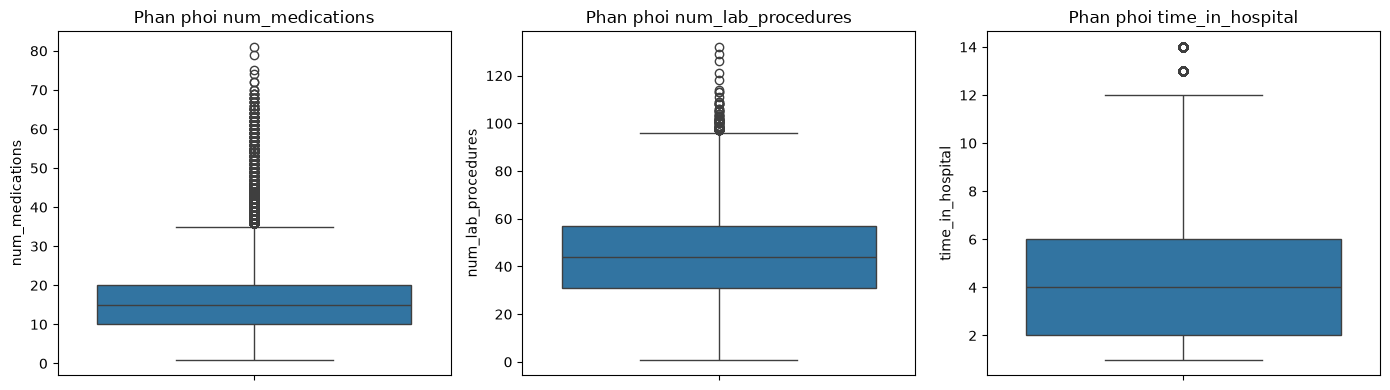

       num_medications  num_lab_procedures  time_in_hospital  number_diagnoses
count     79541.000000        79541.000000      79541.000000      79541.000000
mean         15.983656           42.924027          4.378987          7.398562
std           8.113520           19.575774          2.965798          1.944777
min           1.000000            1.000000          1.000000          1.000000
25%          10.000000           31.000000          2.000000          6.000000
50%          15.000000           44.000000          4.000000          8.000000
75%          20.000000           57.000000          6.000000          9.000000
max          81.000000          132.000000         14.000000         16.000000


In [21]:
# --- 6.5 Outlier / phan phoi cac bien so chinh ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["num_medications", "num_lab_procedures", "time_in_hospital"]):
    sns.boxplot(data=train_df, y=col, ax=ax)
    ax.set_title(f"Phan phoi {col}")
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/outliers_numeric_cols.png", dpi=150)
plt.show()

print(train_df[["num_medications", "num_lab_procedures",
                 "time_in_hospital", "number_diagnoses"]].describe())

## 7. Luu file

In [22]:
train_df.to_csv("../data/train_clean.csv", index=False)
test_df.to_csv("../data/test_clean.csv", index=False)
print("Da luu data/train_clean.csv va data/test_clean.csv")

Da luu data/train_clean.csv va data/test_clean.csv
